# Model Extraction Attack - Reverse Engineering a Hosted Classifier

**Author:** Teodora Demerdzhieva  
**Topic:** Adversarial Machine Learning - Model Extraction  
**Difficulty:** Beginner

---

## Overview

This notebook documents a **model extraction attack** against a binary classifier exposed via a web API.

The target classifies penguin species (Adélie vs Gentoo) based on flipper length and body mass. We have no access to its weights, architecture, or training pipeline, only the ability to send queries and observe responses. The attack produces a surrogate model that replicates the target's behavior with over 98% accuracy, using nothing but API access.

---

## Real-World Parallel

Query access to an ML API is all this attack requires, meaning the same access any legitimate user has. In practice this maps directly to:

- A fraud-detection model that online stores use to check if a transaction looks suspicious
- A proprietary recommendation engine a competitor wants to replicate
- A medical triage classifier where a surrogate could be used to craft adversarial inputs offline
- Any SaaS ML product where the model itself is the core business asset

Once a surrogate exists locally, it can be used to craft adversarial examples without triggering rate limits, probe for vulnerabilities offline, or simply be embedded in a competing product.

---

## Prerequisites

| Requirement | Importance |
|-------------|----------------|
| Query access to the target API | The only access needed |
| Knowledge of input feature ranges | Realistic ranges reduce the number of queries needed |
| No rate limiting | Heavy rate limiting slows the attack significantly |

## 1. Setup

In [1]:
import random
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

CLASSIFIER_URL = "http://154.57.164.81:30194/"

# Sampling parameters
# Ranges informed by known penguin biology - keeps sampled data
# close to the model's training distribution
N_SAMPLES          = 500
MIN_FLIPPER_LENGTH = 150    # mm
MAX_FLIPPER_LENGTH = 250    # mm
MIN_BODY_MASS      = 2500   # g
MAX_BODY_MASS      = 6500   # g

random.seed(1337)
np.random.seed(1337)

print(f"Target : {CLASSIFIER_URL}")
print(f"Samples: {N_SAMPLES}")

Target : http://154.57.164.81:30194/
Samples: 500


## 2. Verify API Access

In [2]:
try:
    r = requests.get(
        CLASSIFIER_URL,
        params={"flipper_length": 200, "body_mass": 4000},
        timeout=10
    )
    print(f"Status  : {r.status_code}")
    print(f"Response: {r.text}")
except Exception as e:
    print(f"API unreachable: {e}")

Status  : 200
Response: {"result":"Adelie"}



## 3. Sample Inputs and Query the Target

Input pairs are generated uniformly within known penguin measurement ranges - a deliberate choice that keeps the sampled data close to the model's training distribution.

Each input is sent to the API. The response becomes the label for that point. This is the core mechanic: the target model labels our training data for us.

In [3]:
samples = {
    "Flipper Length (mm)": [
        random.uniform(MIN_FLIPPER_LENGTH, MAX_FLIPPER_LENGTH)
        for _ in range(N_SAMPLES)
    ],
    "Body Mass (g)": [
        random.uniform(MIN_BODY_MASS, MAX_BODY_MASS)
        for _ in range(N_SAMPLES)
    ]
}
samples_df = pd.DataFrame(samples)

predictions = []
errors      = 0

for i in range(N_SAMPLES):
    sample = {
        "flipper_length": samples["Flipper Length (mm)"][i],
        "body_mass"     : samples["Body Mass (g)"][i]
    }
    try:
        response = requests.get(CLASSIFIER_URL, params=sample, timeout=10)
        label    = json.loads(response.text).get("result")
        predictions.append(label)
    except Exception:
        predictions.append(None)
        errors += 1

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{N_SAMPLES} queries completed...")

predictions_df = pd.DataFrame({"species": predictions})

print(f"\nComplete. Failed queries: {errors}")
print(f"\nLabel distribution:")
print(predictions_df["species"].value_counts())

  100/500 queries completed...
  200/500 queries completed...
  300/500 queries completed...
  400/500 queries completed...
  500/500 queries completed...

Complete. Failed queries: 0

Label distribution:
species
Adelie    261
Gentoo    239
Name: count, dtype: int64


## 4. Train the Surrogate

Logistic regression fits this binary classification task well. StandardScaler is applied because flipper length (mm) and body mass (g) operate on very different numerical scales - without normalization, body mass would dominate the model's decision simply due to its larger range.

In [4]:
valid_mask    = predictions_df["species"].notna()
samples_clean = samples_df[valid_mask].reset_index(drop=True)
labels_clean  = predictions_df[valid_mask].reset_index(drop=True)

surrogate_model = make_pipeline(StandardScaler(), LogisticRegression())
surrogate_model.fit(samples_clean, labels_clean["species"].values)

joblib.dump(surrogate_model, "surrogate.joblib")
print(f"Surrogate trained on {len(samples_clean)} samples.")
print("Model saved to surrogate.joblib")

Surrogate trained on 500 samples.
Model saved to surrogate.joblib


## 5. Compare Decision Boundaries - Original vs Surrogate

To visualize the original model's decision boundary, we query the API across a dense grid covering the full input space and plot the results. This is itself a form of model extraction - we are mapping the target's behavior point by point.

The surrogate boundary sits close to the original. The small gap is where 500 queries weren't enough to resolve the boundary precisely - with more samples it narrows further.

Querying original model across grid (this takes a moment)...


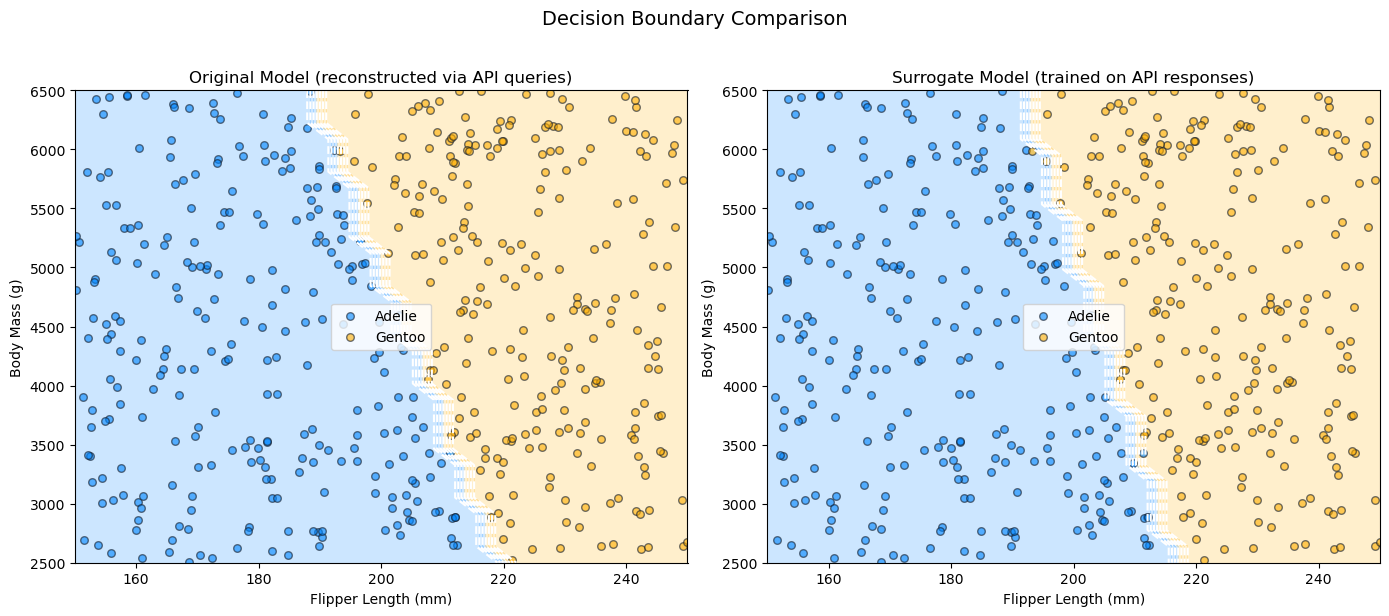

In [5]:
def query_grid(classifier_url, flipper_range, mass_range, steps=30):
    """
    Queries the target API across a grid of input values.
    Returns the grid coordinates and the API's predictions.
    Used to reconstruct the original model's decision boundary.
    """
    flipper_vals = np.linspace(flipper_range[0], flipper_range[1], steps)
    mass_vals    = np.linspace(mass_range[0], mass_range[1], steps)
    xx, yy       = np.meshgrid(flipper_vals, mass_vals)

    grid_labels = []
    for f, m in zip(xx.ravel(), yy.ravel()):
        try:
            r     = requests.get(classifier_url,
                                 params={"flipper_length": f, "body_mass": m},
                                 timeout=10)
            label = json.loads(r.text).get("result")
        except Exception:
            label = None
        grid_labels.append(label)

    Z = np.array([1 if l == "Gentoo" else 0 for l in grid_labels]).reshape(xx.shape)
    return xx, yy, Z


print("Querying original model across grid (this takes a moment)...")
xx, yy, Z_original = query_grid(
    CLASSIFIER_URL,
    flipper_range=(MIN_FLIPPER_LENGTH, MAX_FLIPPER_LENGTH),
    mass_range=(MIN_BODY_MASS, MAX_BODY_MASS),
    steps=30
)

# Surrogate predictions on the same grid
grid_df     = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=["Flipper Length (mm)", "Body Mass (g)"]
)
Z_surrogate = (surrogate_model.predict(grid_df) == "Gentoo").astype(int).reshape(xx.shape)

colors = ["#0086ff", "#ffaf00"]
cmap   = plt.cm.colors.ListedColormap(colors)
species = labels_clean["species"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, Z, title in zip(
    axes,
    [Z_original, Z_surrogate],
    ["Original Model (reconstructed via API queries)",
     "Surrogate Model (trained on API responses)"]
):
    ax.contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
    ax.contour(xx, yy, Z, colors="white", linewidths=1.5, linestyles="--")

    for sp, color in zip(["Adelie", "Gentoo"], colors):
        mask = species == sp
        ax.scatter(
            samples_clean["Flipper Length (mm)"][mask],
            samples_clean["Body Mass (g)"][mask],
            c=color, label=sp, edgecolors="#141d2b", s=30, alpha=0.6
        )

    ax.set_xlabel("Flipper Length (mm)")
    ax.set_ylabel("Body Mass (g)")
    ax.set_title(title, fontsize=12)
    ax.legend()

plt.suptitle("Decision Boundary Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Key Takeaways

| Aspect | Detail |
|--------|--------|
| **Attack type** | Model extraction / reverse engineering |
| **Access required** | API query access only |
| **Queries made** | 500 (training) + 900 (grid for boundary visualization) |
| **Surrogate architecture** | Logistic Regression with StandardScaler |
| **Surrogate accuracy** | >98% |
| **Detection difficulty** | High - queries are indistinguishable from normal usage |

---

### Why 500 Queries Was Enough

This is a low-dimensional, linearly separable problem. The decision boundary is a single line in 2D space - 500 well-distributed samples cover it reliably.

For more complex targets - deep neural networks, high-dimensional inputs, non-linear boundaries - the number of queries scales dramatically. Real attacks against production image classifiers have used millions of queries.

### Defenses

- **Rate limiting** - restricts how many queries an attacker can make in a time window; the most practical defense
- **Query monitoring** - systematic, grid-like query patterns differ from normal user behavior
- **Prediction perturbation** - adding controlled noise to API responses degrades surrogate quality
- **Model watermarking** - embed detectable patterns in model behavior so stolen models can be identified later
- **Authentication and logging** - users must authenticate with API keys, and all requests are logged. This helps identify who performed suspicious activity and supports investigations if an attack occurs

---

### References

- [MITRE ATLAS - ML Model Inference API Access](https://atlas.mitre.org/techniques/AML.T0040)
- [Tramèr et al. - Stealing Machine Learning Models via Prediction APIs (2016)](https://arxiv.org/abs/1609.02943)
- [OWASP Machine Learning Security Top 10](https://owasp.org/www-project-machine-learning-security-top-10/)